In [12]:
import torch
import matplotlib.pyplot as plt
from util import load_model, load_config, value_factor, lcoe
from model import VFNN
from util import load_dataset, load_dataset_no_split, load_experiment
import pandas as pd
import numpy as np
from classical_strategies import base_load, base_load_modified
from tabulate import tabulate

In [30]:
# model_1day, dataset, config = load_experiment('8429e759-7ae6-4338-aa05-8d015681ac09', '../data/processed/dataset_2018-21_clean.csv')
model_1week, dataset, config = load_experiment('8c214393-4e6f-493d-a8d2-6f016a07ac1e', '../data/processed/dataset_2018-21_clean.csv')
# model_1month, _, _ = load_experiment('957a6ccd-475b-4067-8f98-6b16926eb055', '../data/processed/dataset_2018-21_clean.csv')

/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold


In [33]:
idxs1mo = 24 * 30
idxs1yr = 24 * 365
dataset = dataset[:idxs1mo]
print(f'Length of dataset: {len(dataset)}')
power = dataset[:,0].detach().cpu().numpy().squeeze()
price = dataset[:,1].detach().cpu().numpy().squeeze()
x = np.arange(0, len(dataset))

Length of dataset: 720


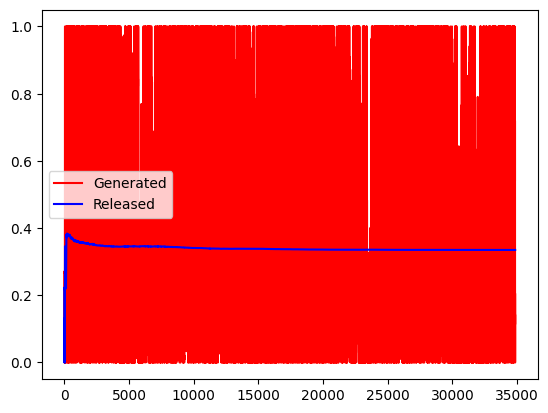

Raw VF: 0.6004442572593689
Modeled VF: 0.9986026287078857
Raw LCOE: 0.00222389935515821
Modeled LCOE: 0.0016325507313013077


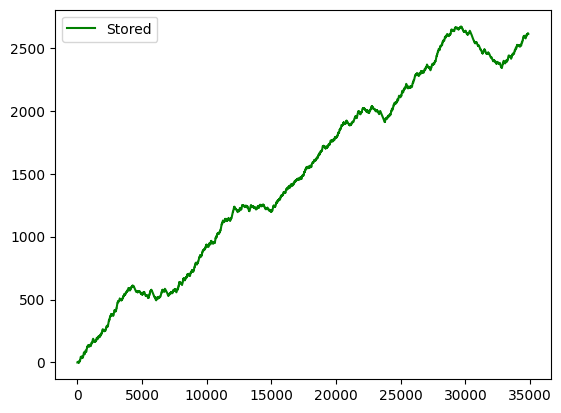

In [15]:
pred = model_1day(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released = pred[:,0]
stored = pred[:,1]

plt.plot(x, power, 'r', label='Generated')
plt.plot(x, released, 'b', label='Released')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
modeled_vf = value_factor(released, price)
before_lcoe = lcoe(power, price)
modeled_lcoe = lcoe(released, price)

print(f'Raw VF: {before_vf}')
print(f'Modeled VF: {modeled_vf}')
print(f'Raw LCOE: {before_lcoe}')
print(f'Modeled LCOE: {modeled_lcoe}')

plt.plot(x, stored, 'g', label='Stored')
plt.legend()
plt.show()

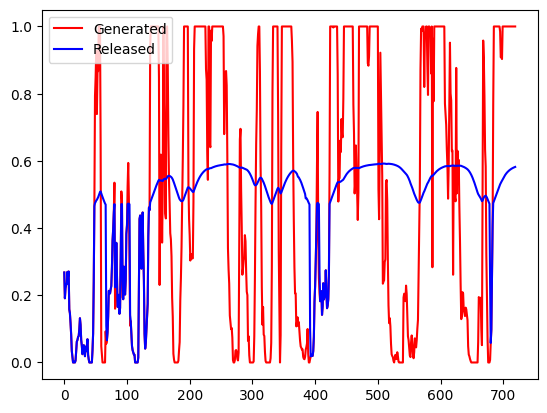

Raw VF: 0.6395956873893738
Modeled 1week VF: 0.9986026287078857
Raw LCOE: 0.08075495809316635
Modeled 1week LCOE: 0.0016325507313013077


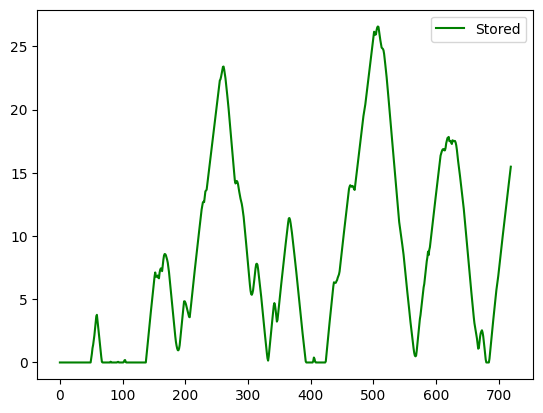

In [34]:
pred = model_1week(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released = pred[:,0]
stored = pred[:,1]

plt.plot(x, power, 'r', label='Generated')
plt.plot(x, released, 'b', label='Released')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
modeled_1week_vf = value_factor(released, price)
before_lcoe = lcoe(power, price)
modeled_1week_lcoe = lcoe(released, price)

print(f'Raw VF: {before_vf}')
print(f'Modeled 1week VF: {modeled_vf}')
print(f'Raw LCOE: {before_lcoe}')
print(f'Modeled 1week LCOE: {modeled_lcoe}')

plt.plot(x, stored, 'g', label='Stored')
plt.legend()
plt.show()

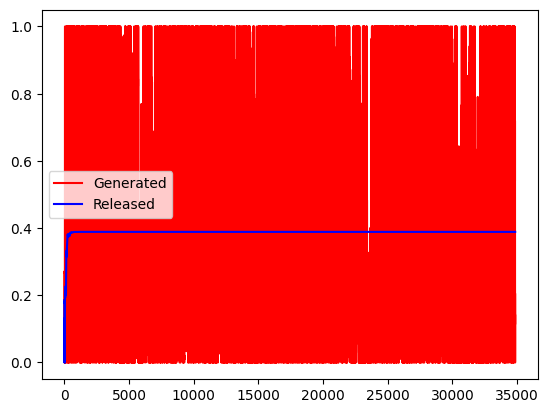

Raw VF: 0.6004442572593689
Modeled 1month VF: 0.9986026287078857
Raw LCOE: 0.00222389935515821
Modeled 1month LCOE: 0.0016325507313013077


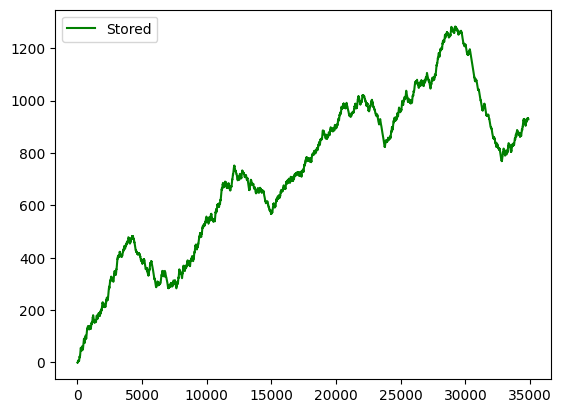

In [29]:
pred = model_1month(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released = pred[:,0]
stored = pred[:,1]

plt.plot(x, power, 'r', label='Generated')
plt.plot(x, released, 'b', label='Released')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
modeled_1month_vf = value_factor(released, price)
before_lcoe = lcoe(power, price)
modeled_1month_lcoe = lcoe(released, price)

print(f'Raw VF: {before_vf}')
print(f'Modeled 1month VF: {modeled_vf}')
print(f'Raw LCOE: {before_lcoe}')
print(f'Modeled 1month LCOE: {modeled_lcoe}')

plt.plot(x, stored, 'g', label='Stored')
plt.legend()
plt.show()

[0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217
 0.49023217 0.49023217 0.49023217 0.49023217 0.49023217 0.4902

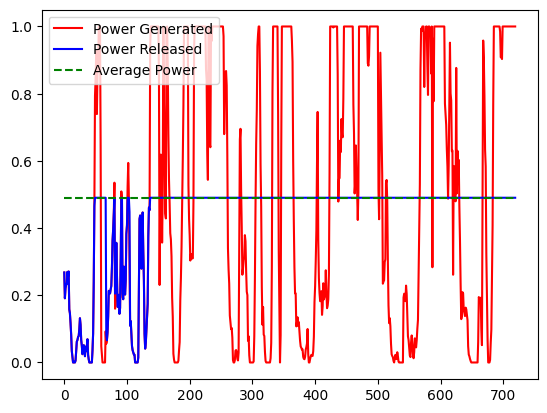

Raw VF: 0.6395956873893738
Baseload VF: 0.962138474791489
Raw LCOE: 0.08075495809316635
Baseload LCOE: 0.06003420226625823


In [35]:
base_load_released = base_load(power)

avg = np.repeat(np.mean(power), len(x))
print(avg)
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
baseload_vf = value_factor(base_load_released, price)
before_lcoe = lcoe(power, price)
baseload_lcoe = lcoe(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Baseload VF: {baseload_vf}')
print(f'Raw LCOE: {before_lcoe}')
print(f'Baseload LCOE: {baseload_lcoe}')

In [19]:
metrics = np.array([["Raw", before_vf, before_lcoe], ["Baseload", baseload_vf, baseload_lcoe], ["1 Day Model", modeled_vf, modeled_lcoe], ["1 Week Model", modeled_1week_vf, modeled_1week_lcoe], ["1 Month Model", modeled_1month_vf, modeled_1month_lcoe]])
headers = ["Strategy", "VF", "LCOE"]

# Generate the table in fancy format.
table = tabulate(metrics, headers, tablefmt="fancy_grid")

print(table)

╒═══════════════╤══════════╤════════════╕
│ Strategy      │       VF │       LCOE │
╞═══════════════╪══════════╪════════════╡
│ Raw           │ 0.600444 │ 0.0022239  │
├───────────────┼──────────┼────────────┤
│ Baseload      │ 0.992815 │ 0.0013551  │
├───────────────┼──────────┼────────────┤
│ 1 Day Model   │ 0.998603 │ 0.00163255 │
├───────────────┼──────────┼────────────┤
│ 1 Week Model  │ 0.973991 │ 0.00137687 │
├───────────────┼──────────┼────────────┤
│ 1 Month Model │ 0.999625 │ 0.00316909 │
╘═══════════════╧══════════╧════════════╛


0.41416743


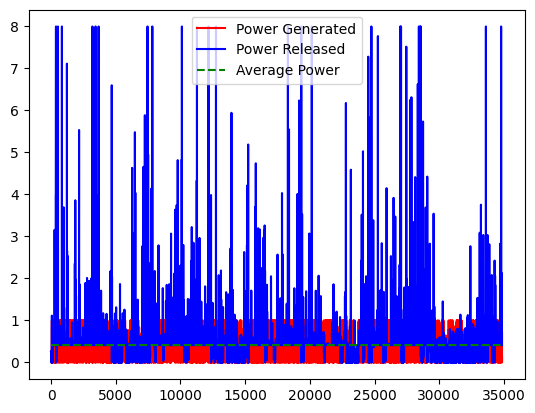

Raw VF: 0.6004442572593689
Modified Base Load VF: 1.636142385417328


In [20]:
base_load_released = base_load_modified(power, price)

avg = np.repeat(np.mean(power), len(x))
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
after_vf = value_factor(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Modified Base Load VF: {after_vf}')